<a href="https://colab.research.google.com/github/asegura4488/EDCO_MachineLearning/blob/main/Semana3/RegresionLogisticaMultiClase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# ============================================================
# REGRESIÓN LOGÍSTICA MULTICLASE
# Dataset: Iris
#
# Clases:
# 0 = setosa
# 1 = versicolor
# 2 = virginica
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.preprocessing import (
    StandardScaler,
    label_binarize # One hot-encoding para varias clases
    #[0,1,2] -> [1,0,0], [0,1,0], [0,0,1]
)

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)


# ============================================================
# 1. CARGAR DATASET
# ============================================================

datos = load_iris(as_frame=True)

In [16]:
X = datos.data
y = datos.target

nombres_clases = datos.target_names

In [17]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [69]:
X.mean(axis = 0)

,0
sepal length (cm),5.843333
sepal width (cm),3.057333
petal length (cm),3.758000
petal width (cm),1.199333


In [70]:
X.std(axis = 0)

,0
sepal length (cm),0.828066
sepal width (cm),0.435866
petal length (cm),1.765298
petal width (cm),0.762238


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y # Datos desbalanceados
)

In [25]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [26]:
# ============================================================
# 3. PIPELINE
# ============================================================

modelo = Pipeline([
    ("scaler", StandardScaler()),

    ("logreg", LogisticRegression(
        solver="lbfgs",
        C=1.0,
        max_iter=5000
    ))
])


# ============================================================
# 4. VALIDACIÓN CRUZADA
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_cv = cross_validate(
    modelo,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "roc_auc_ovr"
    ]
)

In [27]:
print("\n================ VALIDACIÓN CRUZADA ================\n")

metricas = [
    "test_accuracy",
    "test_precision_macro",
    "test_recall_macro",
    "test_f1_macro",
    "test_roc_auc_ovr"
]

for metrica in metricas:

    media = resultados_cv[metrica].mean()
    desviacion = resultados_cv[metrica].std()

    print(
        f"{metrica:25s}: "
        f"{media:.3f} +- {desviacion:.3f}"
    )




================ VALIDACIÓN CRUZADA ================

test_accuracy            : 0.965 +- 0.051
test_precision_macro     : 0.967 +- 0.050
test_recall_macro        : 0.963 +- 0.053
test_f1_macro            : 0.964 +- 0.053
test_roc_auc_ovr         : 0.995 +- 0.007


In [28]:
modelo.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=5000))])

In [29]:
# Vamos a hacer predicciones
y_pred = modelo.predict(X_test)
y_pred

array([0, 1, 1, 1, 0, 1, 1, 2, 2, 2, 1, 2, 1, 1, 0, 0, 0, 1, 0, 1, 2, 1,
       2, 1, 2, 1, 0, 2, 0, 2, 2, 2, 0, 0, 0, 0, 2, 1])

In [32]:
y_prob = modelo.predict_proba(X_test)
np.round(y_prob,2)

array([[0.98, 0.02, 0.  ],
       [0.03, 0.62, 0.35],
       [0.05, 0.88, 0.07],
       [0.01, 0.92, 0.07],
       [0.97, 0.03, 0.  ],
       [0.1 , 0.63, 0.26],
       [0.  , 0.55, 0.45],
       [0.  , 0.05, 0.95],
       [0.  , 0.09, 0.91],
       [0.  , 0.04, 0.96],
       [0.02, 0.57, 0.41],
       [0.  , 0.02, 0.98],
       [0.03, 0.95, 0.03],
       [0.08, 0.71, 0.21],
       [0.98, 0.02, 0.  ],
       [0.98, 0.02, 0.  ],
       [0.94, 0.06, 0.  ],
       [0.02, 0.78, 0.2 ],
       [0.99, 0.01, 0.  ],
       [0.06, 0.86, 0.08],
       [0.  , 0.15, 0.85],
       [0.06, 0.93, 0.01],
       [0.01, 0.4 , 0.59],
       [0.03, 0.75, 0.22],
       [0.  , 0.22, 0.78],
       [0.11, 0.89, 0.01],
       [0.61, 0.39, 0.  ],
       [0.01, 0.37, 0.63],
       [0.98, 0.02, 0.  ],
       [0.  , 0.43, 0.57],
       [0.  , 0.15, 0.85],
       [0.  , 0.04, 0.96],
       [1.  , 0.  , 0.  ],
       [0.97, 0.03, 0.  ],
       [0.96, 0.04, 0.  ],
       [0.93, 0.07, 0.  ],
       [0.  , 0.04, 0.96],
 

In [34]:
tabla_pred = pd.DataFrame(
    {
        "Real": y_test.values,
        "Predicción": y_pred,
        "Probabilidad setosa": y_prob[:,0].round(2),
        "Probabilidad versicolor": y_prob[:,1].round(2),
        "Probabilidad virginica": y_prob[:,2].round(2)
    }
)

In [36]:
tabla_pred.head(5)

,Real,Predicción,Probabilidad setosa,Probabilidad versicolor,Probabilidad virginica
0,0,0,0.98,0.02,0.00
1,1,1,0.03,0.62,0.35
2,1,1,0.05,0.88,0.07
3,1,1,0.01,0.92,0.07
4,0,0,0.97,0.03,0.00


In [37]:
# Metricas
acurracy = accuracy_score(y_test, y_pred)
acurracy

0.9210526315789473

In [39]:
precision_macro = precision_score(y_test, y_pred, average="macro") # Una media normal
precision_macro

0.9246031746031745

In [40]:
recall_macro = recall_score(y_test, y_pred, average="macro")
recall_macro

0.923076923076923

In [41]:
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_macro

0.9229629629629629

In [42]:
# Como consideramos el tamaño de cada clase en la muestra?
precision_weighted = precision_score(y_test, y_pred, average="# ")
precision_weighted

0.9226190476190477

In [44]:
# ROC - AUC multiclase
roc_auc_ovr = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr"
)
roc_auc_ovr

#Que signfica OVR
# One vs Rest -> una clase contra el resto


np.float64(0.9958974358974361)

In [46]:
print(classification_report(
    y_test,
    y_pred,
    target_names=nombres_clases
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



In [47]:
# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)
cm

array([[12,  0,  0],
       [ 0, 12,  1],
       [ 0,  2, 11]])

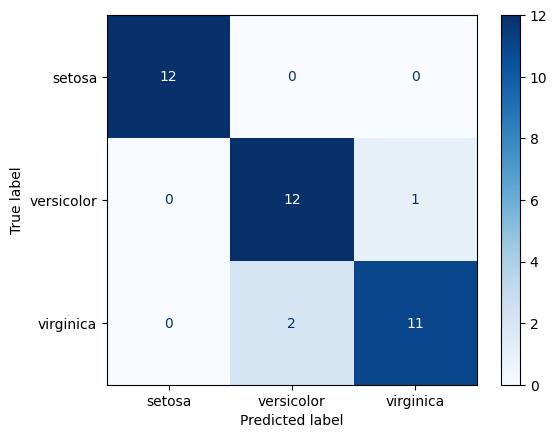

In [48]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=nombres_clases,
    cmap="Blues"
)

In [50]:
# Vamos a mirar la curva ROC, en los tres canales
y_test_bin = label_binarize(y_test, classes=[0,1,2])
#y_test_bin

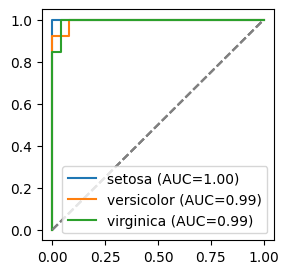

In [59]:
plt.figure(figsize=(3,3))

for i, nombre in enumerate(nombres_clases):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:,i],
        y_prob[:,i]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{nombre} (AUC={roc_auc_score(y_test_bin[:,i], y_prob[:,i]):.2f})"
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle="--",
        color="gray"
    )

plt.legend()

In [61]:
# MIremos el modelo
coeficientes = modelo.named_steps[
    "logreg"
].coef_

In [62]:
tabla_coeficientes = pd.DataFrame(
    coeficientes,
    columns=datos.feature_names,
    index=nombres_clases
)

In [63]:
tabla_coeficientes

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,-1.049416,1.15349,-1.628645,-1.567816
versicolor,0.495376,-0.53076,-0.263881,-0.808387
virginica,0.554040,-0.62273,1.892526,2.376203


In [64]:
np.exp(0.05)

np.float64(1.0512710963760241)

In [65]:
np.exp(-1.049416)

np.float64(0.35014217244243906)

In [66]:
np.exp(0.495376)

np.float64(1.6411151823730044)

In [68]:
tabla_coeficientes.apply(lambda x: np.exp(x) ) # Bodoo pandas

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,0.350142,3.169233,0.196195,0.208500
versicolor,1.641116,0.588158,0.768065,0.445576
virginica,1.740269,0.536478,6.636109,10.763951
